In [2]:
import pandas as pd
import os
import glob

In [3]:
# Folder path
folder_path = r"C:\Users\Anasua Mazumder\Documents\S126 PRT564 DATA ANALYTICS AND VISUALISATION Assignment\Fuel Dataset"


In [4]:
# Try loading as Excel files
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

In [5]:
# Check what files are in your folder
import os

folder_path = r"C:\Users\Anasua Mazumder\Documents\S126 PRT564 DATA ANALYTICS AND VISUALISATION Assignment\Fuel Dataset"

files = os.listdir(folder_path)
print("Files found:")
for f in files[:5]:  # show first 5 files
    print(f)

Files found:
FuelWatchRetail-01-2023.csv
FuelWatchRetail-01-2024.csv
FuelWatchRetail-01-2025.csv
FuelWatchRetail-01-2026.csv
FuelWatchRetail-02-2023.csv


In [6]:
import pandas as pd
import glob
import os

folder_path = r"C:\Users\Anasua Mazumder\Documents\S126 PRT564 DATA ANALYTICS AND VISUALISATION Assignment\Fuel Dataset"

# Load all CSV files
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

# Merge all into one dataframe
df = pd.concat(df_list, ignore_index=True)

print(" Total files loaded:", len(all_files))
print(" Total rows:", len(df))
print(" Columns:", df.columns.tolist())
print("\n First 5 rows:")
df.head()

 Total files loaded: 40
 Total rows: 3314312
 Columns: ['PUBLISH_DATE', 'TRADING_NAME', 'BRAND_DESCRIPTION', 'PRODUCT_DESCRIPTION', 'PRODUCT_PRICE', 'ADDRESS', 'LOCATION', 'POSTCODE', 'AREA_DESCRIPTION', 'REGION_DESCRIPTION', 'Unnamed: 10']

 First 5 rows:


,PUBLISH_DATE,TRADING_NAME,BRAND_DESCRIPTION,PRODUCT_DESCRIPTION,PRODUCT_PRICE,ADDRESS,LOCATION,POSTCODE,AREA_DESCRIPTION,REGION_DESCRIPTION,Unnamed: 10
0,01/01/2023,53 Mile Roadhouse,United,ULP,170.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel,NaN
1,01/01/2023,53 Mile Roadhouse,United,Diesel,202.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel,NaN
2,01/01/2023,53 Mile Roadhouse,United,98 RON,187.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel,NaN
3,01/01/2023,7-Eleven Ascot,7-Eleven,ULP,161.9,194 Great Eastern Hwy,ASCOT,6104,South of River,Metro,NaN
4,01/01/2023,7-Eleven Ascot,7-Eleven,Brand Diesel,195.9,194 Great Eastern Hwy,ASCOT,6104,South of River,Metro,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3314312 entries, 0 to 3314311
Data columns (total 11 columns):
 #   Column               Dtype  
---  ------               -----  
 0   PUBLISH_DATE         str    
 1   TRADING_NAME         str    
 2   BRAND_DESCRIPTION    str    
 3   PRODUCT_DESCRIPTION  str    
 4   PRODUCT_PRICE        float64
 5   ADDRESS              str    
 6   LOCATION             str    
 7   POSTCODE             int64  
 8   AREA_DESCRIPTION     str    
 9   REGION_DESCRIPTION   str    
 10  Unnamed: 10          float64
dtypes: float64(2), int64(1), str(8)
memory usage: 278.1 MB


In [8]:
df.isnull()

,PUBLISH_DATE,TRADING_NAME,BRAND_DESCRIPTION,PRODUCT_DESCRIPTION,PRODUCT_PRICE,ADDRESS,LOCATION,POSTCODE,AREA_DESCRIPTION,REGION_DESCRIPTION,Unnamed: 10
0,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
3314307,False,False,False,False,False,False,False,False,False,False,True
3314308,False,False,False,False,False,False,False,False,False,False,True
3314309,False,False,False,False,False,False,False,False,False,False,True
3314310,False,False,False,False,False,False,False,False,False,False,True


In [10]:
df.describe()

,PRODUCT_PRICE,POSTCODE,Unnamed: 10
count,3.314312e+06,3.314312e+06,0.0
mean,1.937812e+02,6.198668e+03,NaN
std,2.443727e+01,1.835607e+02,NaN
min,1.097000e+02,6.000000e+03,NaN
25%,1.799000e+02,6.065000e+03,NaN
50%,1.900000e+02,6.155000e+03,NaN
75%,2.039000e+02,6.239000e+03,NaN
max,3.973000e+02,6.765000e+03,NaN


In [11]:
# ============================================
# STEP 2: DATA CLEANING & PREPROCESSING
# ============================================

# Drop unnamed empty column
df = df.drop(columns=['Unnamed: 10'], errors='ignore')

# Convert date column
df['PUBLISH_DATE'] = pd.to_datetime(df['PUBLISH_DATE'], dayfirst=True)

# Extract date features
df['YEAR'] = df['PUBLISH_DATE'].dt.year
df['MONTH'] = df['PUBLISH_DATE'].dt.month
df['DAY'] = df['PUBLISH_DATE'].dt.day
df['DAY_OF_WEEK'] = df['PUBLISH_DATE'].dt.dayofweek
df['QUARTER'] = df['PUBLISH_DATE'].dt.quarter

# Drop rows where PRODUCT_PRICE is missing
df = df.dropna(subset=['PRODUCT_PRICE'])

# Remove unrealistic prices
df = df[(df['PRODUCT_PRICE'] >= 50) & (df['PRODUCT_PRICE'] <= 400)]

# Check results
print(" Unnamed column removed")
print(" Date converted")
print(" New columns added: YEAR, MONTH, DAY, DAY_OF_WEEK, QUARTER")
print("\n=== Dataset Shape ===")
print(df.shape)

print("\n=== Fuel Types ===")
print(df['PRODUCT_DESCRIPTION'].value_counts())

print("\n=== Regions ===")
print(df['REGION_DESCRIPTION'].value_counts())

print("\n=== Updated Columns ===")
print(df.columns.tolist())

df.head()

 Unnamed column removed
 Date converted
 New columns added: YEAR, MONTH, DAY, DAY_OF_WEEK, QUARTER

=== Dataset Shape ===
(3314312, 15)

=== Fuel Types ===
PRODUCT_DESCRIPTION
ULP             857457
98 RON          753598
PULP            574885
Diesel          527665
Brand Diesel    505978
LPG              78505
E85              16224
Name: count, dtype: int64

=== Regions ===
REGION_DESCRIPTION
Metro                   2140988
South-West               364736
Peel                     176141
Wheatbelt                126219
Great Southern           121441
Mid-West                 103872
Goldfields-Esperance      98687
Pilbara                   89071
Kimberley                 55130
Gascoyne                  38027
Name: count, dtype: int64

=== Updated Columns ===
['PUBLISH_DATE', 'TRADING_NAME', 'BRAND_DESCRIPTION', 'PRODUCT_DESCRIPTION', 'PRODUCT_PRICE', 'ADDRESS', 'LOCATION', 'POSTCODE', 'AREA_DESCRIPTION', 'REGION_DESCRIPTION', 'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'QUARTER']


,PUBLISH_DATE,TRADING_NAME,BRAND_DESCRIPTION,PRODUCT_DESCRIPTION,PRODUCT_PRICE,ADDRESS,LOCATION,POSTCODE,AREA_DESCRIPTION,REGION_DESCRIPTION,YEAR,MONTH,DAY,DAY_OF_WEEK,QUARTER
0,2023-01-01,53 Mile Roadhouse,United,ULP,170.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel,2023,1,1,6,1
1,2023-01-01,53 Mile Roadhouse,United,Diesel,202.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel,2023,1,1,6,1
2,2023-01-01,53 Mile Roadhouse,United,98 RON,187.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel,2023,1,1,6,1
3,2023-01-01,7-Eleven Ascot,7-Eleven,ULP,161.9,194 Great Eastern Hwy,ASCOT,6104,South of River,Metro,2023,1,1,6,1
4,2023-01-01,7-Eleven Ascot,7-Eleven,Brand Diesel,195.9,194 Great Eastern Hwy,ASCOT,6104,South of River,Metro,2023,1,1,6,1


In [12]:
df.isnull()

,PUBLISH_DATE,TRADING_NAME,BRAND_DESCRIPTION,PRODUCT_DESCRIPTION,PRODUCT_PRICE,ADDRESS,LOCATION,POSTCODE,AREA_DESCRIPTION,REGION_DESCRIPTION,YEAR,MONTH,DAY,DAY_OF_WEEK,QUARTER
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3314307,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3314308,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3314309,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3314310,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3314312 entries, 0 to 3314311
Data columns (total 15 columns):
 #   Column               Dtype         
---  ------               -----         
 0   PUBLISH_DATE         datetime64[us]
 1   TRADING_NAME         str           
 2   BRAND_DESCRIPTION    str           
 3   PRODUCT_DESCRIPTION  str           
 4   PRODUCT_PRICE        float64       
 5   ADDRESS              str           
 6   LOCATION             str           
 7   POSTCODE             int64         
 8   AREA_DESCRIPTION     str           
 9   REGION_DESCRIPTION   str           
 10  YEAR                 int32         
 11  MONTH                int32         
 12  DAY                  int32         
 13  DAY_OF_WEEK          int32         
 14  QUARTER              int32         
dtypes: datetime64[us](1), float64(1), int32(5), int64(1), str(7)
memory usage: 316.1 MB


In [14]:
df.describe()

,PUBLISH_DATE,PRODUCT_PRICE,POSTCODE,YEAR,MONTH,DAY,DAY_OF_WEEK,QUARTER
count,3314312,3.314312e+06,3.314312e+06,3.314312e+06,3.314312e+06,3.314312e+06,3.314312e+06,3.314312e+06
mean,2024-08-28 18:41:39.524728,1.937812e+02,6.198668e+03,2.024190e+03,6.158346e+00,1.562284e+01,2.998334e+00,2.390552e+00
min,2023-01-01 00:00:00,1.097000e+02,6.000000e+03,2.023000e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,2023-11-04 00:00:00,1.799000e+02,6.065000e+03,2.023000e+03,3.000000e+00,8.000000e+00,1.000000e+00,1.000000e+00
50%,2024-08-31 00:00:00,1.900000e+02,6.155000e+03,2.024000e+03,6.000000e+00,1.600000e+01,3.000000e+00,2.000000e+00
75%,2025-06-25 00:00:00,2.039000e+02,6.239000e+03,2.025000e+03,9.000000e+00,2.300000e+01,5.000000e+00,3.000000e+00
max,2026-04-14 00:00:00,3.973000e+02,6.765000e+03,2.026000e+03,1.200000e+01,3.100000e+01,6.000000e+00,4.000000e+00
std,NaN,2.443727e+01,1.835607e+02,9.624351e-01,3.523997e+00,8.798177e+00,2.001844e+00,1.141025e+00


In [15]:
# ============================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

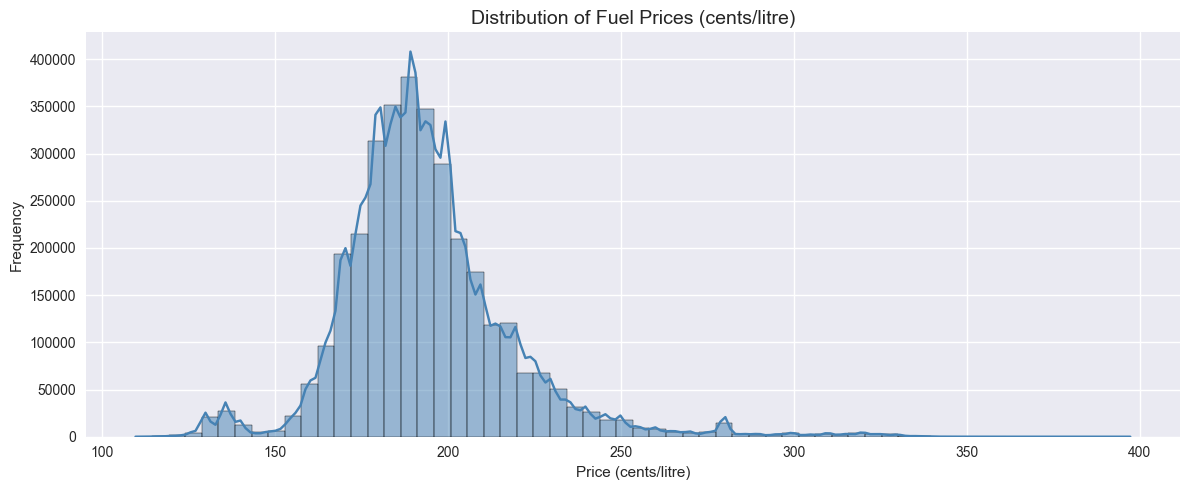

 Plot 1 done - Price Distribution


In [16]:

plt.style.use('seaborn-v0_8')

# --- Plot 1: Distribution of Fuel Prices ---
plt.figure(figsize=(12, 5))
sns.histplot(df['PRODUCT_PRICE'], bins=60, color='steelblue', kde=True)
plt.title('Distribution of Fuel Prices (cents/litre)', fontsize=14)
plt.xlabel('Price (cents/litre)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot1_price_distribution.png')
plt.show()
print(" Plot 1 done - Price Distribution")


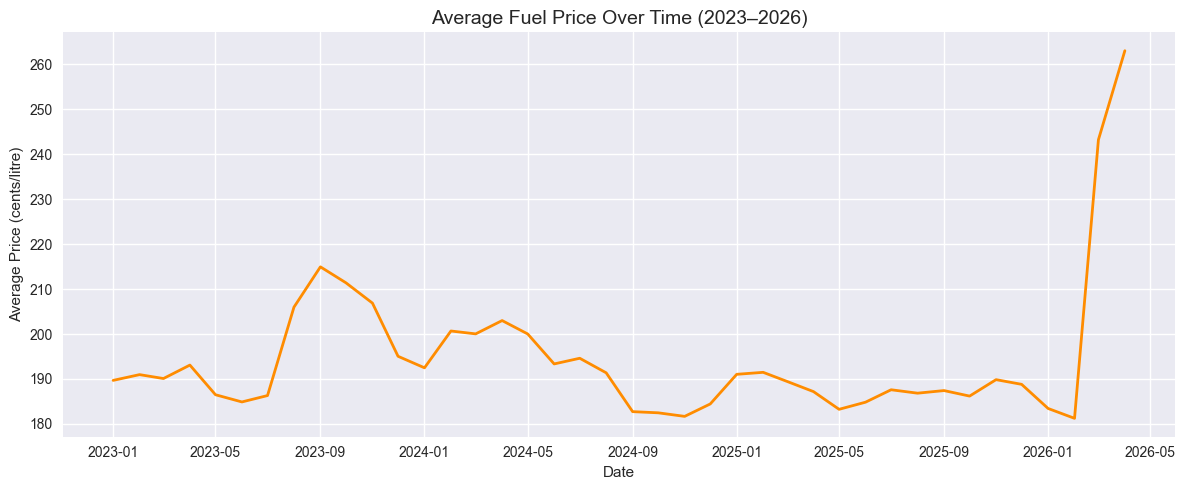

✅ Plot 2 done - Price Over Time


In [19]:
# --- Plot 2: Average Price Over Time ---
monthly_avg = df.groupby(['YEAR', 'MONTH'])['PRODUCT_PRICE'].mean().reset_index()
monthly_avg['DATE'] = pd.to_datetime(monthly_avg[['YEAR', 'MONTH']].assign(DAY=1))

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg['DATE'], monthly_avg['PRODUCT_PRICE'], 
         color='darkorange', linewidth=2)
plt.title('Average Fuel Price Over Time (2023–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Price (cents/litre)')
plt.tight_layout()
plt.savefig('plot2_price_over_time.png')
plt.show()
print(" Plot 2 done - Price Over Time")

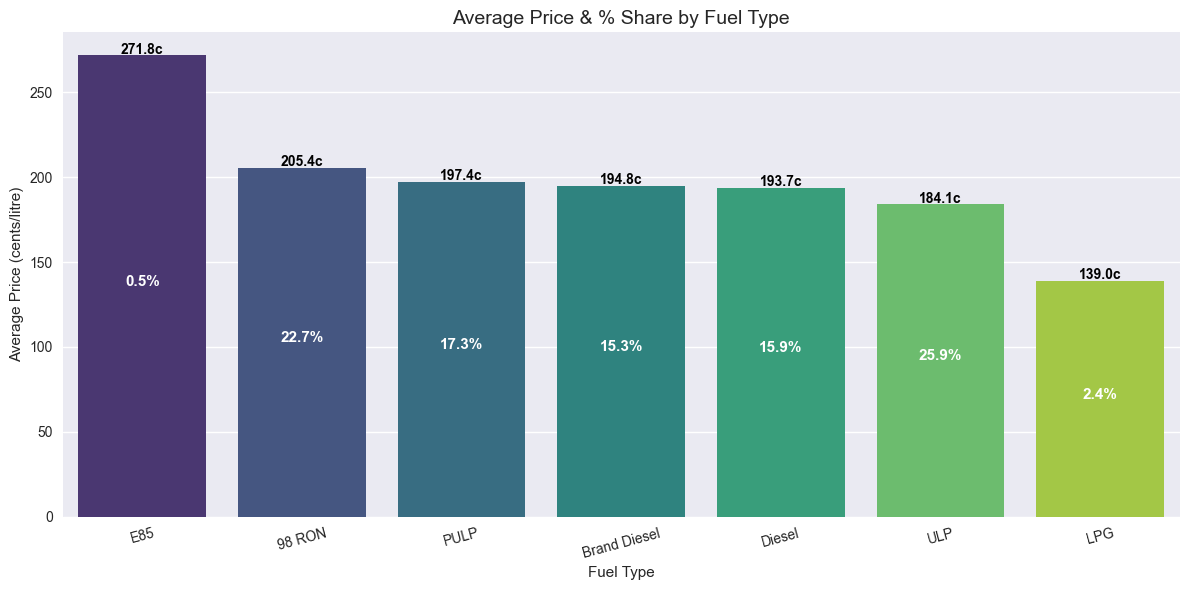


=== Fuel Type Summary ===
                     Avg Price (cents)   Count  % Share
PRODUCT_DESCRIPTION                                    
98 RON                           205.4  753598     22.7
Brand Diesel                     194.8  505978     15.3
Diesel                           193.7  527665     15.9
E85                              271.8   16224      0.5
LPG                              139.0   78505      2.4
PULP                             197.4  574885     17.3
ULP                              184.1  857457     25.9


In [17]:
# PLOT 3 - Bar chart with % share labels on bars
plt.figure(figsize=(12, 6))

fuel_avg = df.groupby('PRODUCT_DESCRIPTION')['PRODUCT_PRICE'].mean().sort_values(ascending=False)
fuel_counts = df['PRODUCT_DESCRIPTION'].value_counts()
fuel_pct = (fuel_counts / fuel_counts.sum() * 100).round(1)

# Reorder pct to match fuel_avg order
fuel_pct_ordered = fuel_pct.reindex(fuel_avg.index)

ax = sns.barplot(x=fuel_avg.index, y=fuel_avg.values, palette='viridis')

# Add price AND % share on each bar
for i, (price, pct) in enumerate(zip(fuel_avg.values, fuel_pct_ordered.values)):
    ax.text(i, price + 1, f'{price:.1f}c', ha='center', 
            fontsize=10, fontweight='bold', color='black')
    ax.text(i, price/2, f'{pct}%', ha='center', 
            fontsize=11, fontweight='bold', color='white')

plt.title('Average Price & % Share by Fuel Type', fontsize=14)
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (cents/litre)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot3_fueltype_final.png', dpi=150)
plt.show()

print("\n=== Fuel Type Summary ===")
summary = pd.DataFrame({
    'Avg Price (cents)': fuel_avg.round(1),
    'Count': fuel_counts,
    '% Share': fuel_pct
})
print(summary)

C:\Users\Anasua Mazumder\AppData\Local\Temp\ipykernel_16180\3844813823.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.index, y=region_avg.values, palette='coolwarm')


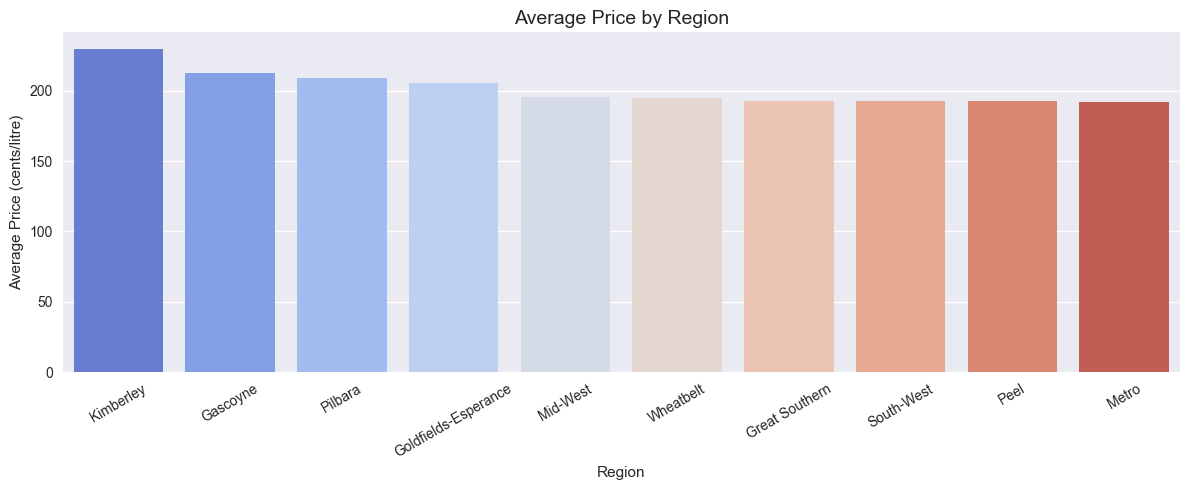

✅ Plot 4 done - Price by Region


In [24]:
# --- Plot 4: Average Price by Region ---
plt.figure(figsize=(12, 5))
region_avg = df.groupby('REGION_DESCRIPTION')['PRODUCT_PRICE'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.index, y=region_avg.values, palette='coolwarm')
plt.title('Average Price by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Average Price (cents/litre)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot4_price_by_region.png')
plt.show()
print(" Plot 4 done - Price by Region")

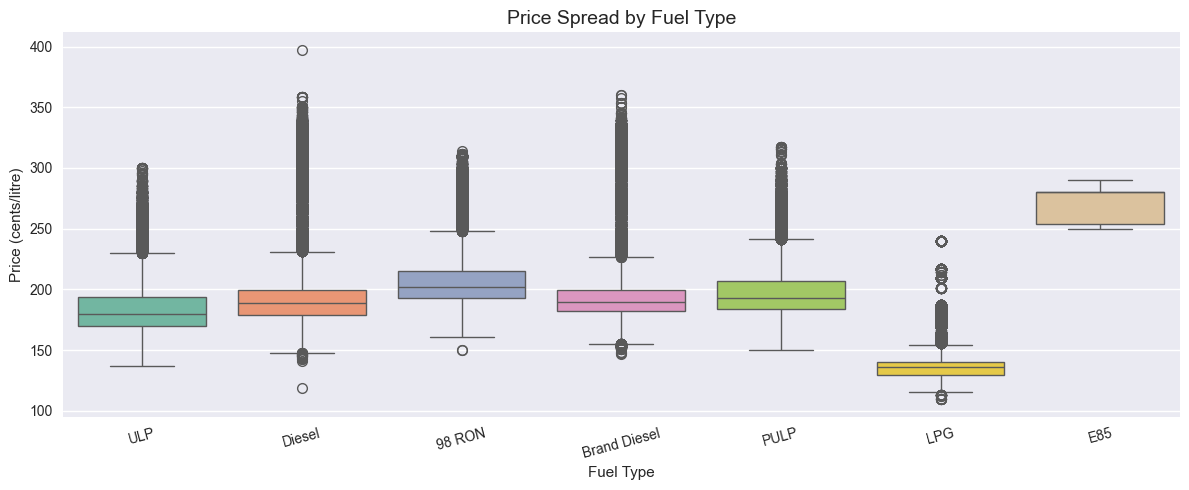

 Plot 5 done - Boxplot by Fuel Type


In [18]:
# --- Plot 5: Boxplot - Price by Fuel Type ---
plt.figure(figsize=(12, 5))
sns.boxplot(x='PRODUCT_DESCRIPTION', y='PRODUCT_PRICE', 
            data=df, palette='Set2')
plt.title('Price Spread by Fuel Type', fontsize=14)
plt.xlabel('Fuel Type')
plt.ylabel('Price (cents/litre)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot5_boxplot_fueltype.png')
plt.show()
print(" Plot 5 done - Boxplot by Fuel Type")

C:\Users\Anasua Mazumder\AppData\Local\Temp\ipykernel_16180\713660972.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=days, y=day_avg.values, palette='Blues_d')


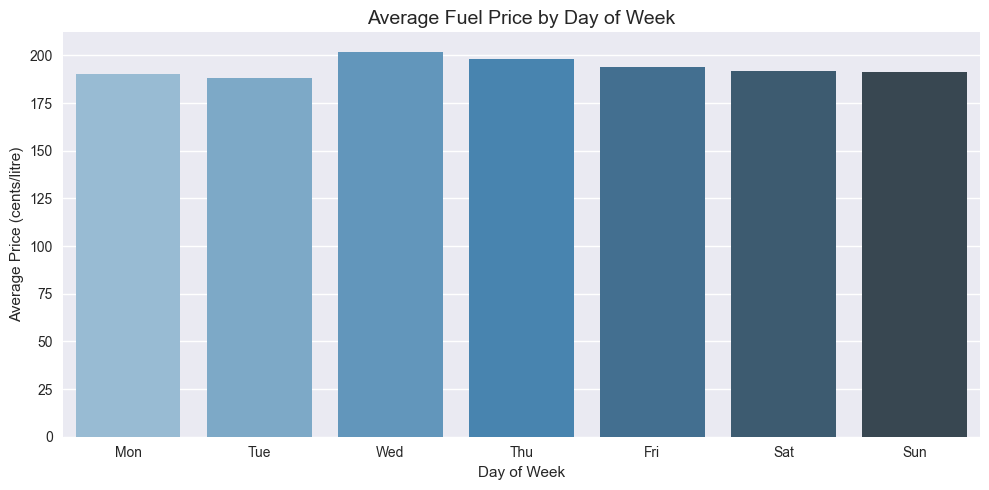

✅ Plot 6 done - Price by Day of Week


In [26]:
# --- Plot 6: Average Price by Day of Week ---
plt.figure(figsize=(10, 5))
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_avg = df.groupby('DAY_OF_WEEK')['PRODUCT_PRICE'].mean()
sns.barplot(x=days, y=day_avg.values, palette='Blues_d')
plt.title('Average Fuel Price by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Average Price (cents/litre)')
plt.tight_layout()
plt.savefig('plot6_price_by_dayofweek.png')
plt.show()
print(" Plot 6 done - Price by Day of Week")

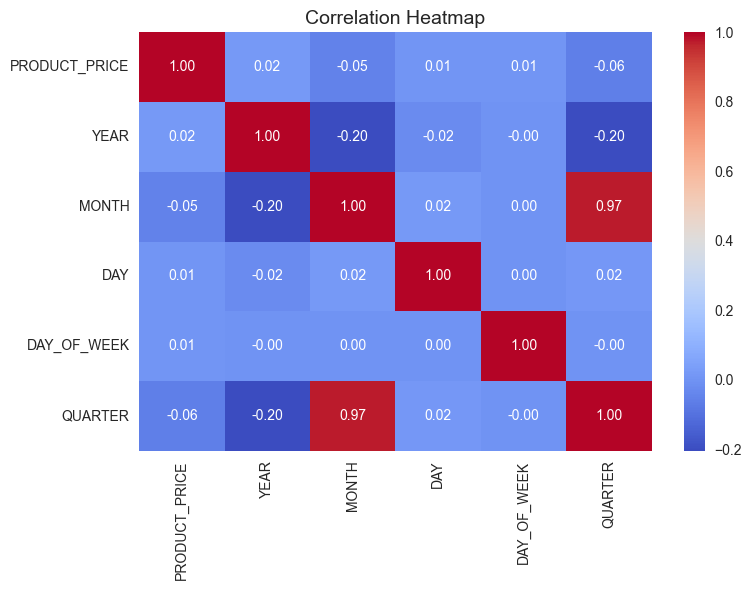

 Plot 7 done - Correlation Heatmap
All 7 EDA plots generated and saved!


In [19]:
# --- Plot 7: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
numeric_cols = df[['PRODUCT_PRICE', 'YEAR', 'MONTH', 
                    'DAY', 'DAY_OF_WEEK', 'QUARTER']]
sns.heatmap(numeric_cols.corr(), annot=True, 
            cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('plot7_correlation_heatmap.png')
plt.show()
print(" Plot 7 done - Correlation Heatmap")

print("All 7 EDA plots generated and saved!")

In [ ]:
#Step 4 — Regression Modelling

In [20]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- Load all CSV files ---
folder_path = r"C:\Users\Anasua Mazumder\Documents\S126 PRT564 DATA ANALYTICS AND VISUALISATION Assignment\Fuel Dataset"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print(f" Loaded {len(all_files)} files | {len(df):,} rows")

# --- Clean Data ---
df = df.drop(columns=['Unnamed: 10'], errors='ignore')
df['PUBLISH_DATE'] = pd.to_datetime(df['PUBLISH_DATE'], dayfirst=True)
df['YEAR'] = df['PUBLISH_DATE'].dt.year
df['MONTH'] = df['PUBLISH_DATE'].dt.month
df['DAY'] = df['PUBLISH_DATE'].dt.day
df['DAY_OF_WEEK'] = df['PUBLISH_DATE'].dt.dayofweek
df['QUARTER'] = df['PUBLISH_DATE'].dt.quarter
df = df.dropna(subset=['PRODUCT_PRICE'])
df = df[(df['PRODUCT_PRICE'] >= 50) & (df['PRODUCT_PRICE'] <= 400)]
print(f" Data cleaned | Shape: {df.shape}")

# --- Encode Categorical Columns ---
le_fuel = LabelEncoder()
le_region = LabelEncoder()
le_brand = LabelEncoder()

df['FUEL_ENCODED'] = le_fuel.fit_transform(df['PRODUCT_DESCRIPTION'])
df['REGION_ENCODED'] = le_region.fit_transform(df['REGION_DESCRIPTION'])
df['BRAND_ENCODED'] = le_brand.fit_transform(df['BRAND_DESCRIPTION'])
print(" Categorical columns encoded")

# --- Features & Target ---
features = ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK',
            'QUARTER', 'FUEL_ENCODED', 'REGION_ENCODED',
            'BRAND_ENCODED']

X = df[features]
y = df['PRODUCT_PRICE']

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"✅ Training set: {len(X_train):,} rows")
print(f"✅ Testing set:  {len(X_test):,} rows")
print(" Ready to train models!")

 Loaded 40 files | 3,314,312 rows
 Data cleaned | Shape: (3314312, 15)
 Categorical columns encoded
✅ Training set: 2,651,449 rows
✅ Testing set:  662,863 rows
 Ready to train models!


In [ ]:
# ============================================
# STEP 5: TRAIN ALL 3 MODELS
# ============================================

In [21]:
# --- Model 1: Linear Regression ---
print("⏳ Training Model 1: Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("✅ Model 1: Linear Regression done!")

⏳ Training Model 1: Linear Regression...
✅ Model 1: Linear Regression done!


In [22]:
# --- Model 2: Ridge Regression ---
print("⏳ Training Model 2: Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print(" Model 2: Ridge Regression done!")

# --- Model 3: Random Forest ---
print("\n Training Model 3: Random Forest...")
print("   (This may take 3-5 minutes - please wait...)")
rf = RandomForestRegressor(n_estimators=100,
                            random_state=42,
                            n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(" Model 3: Random Forest done!")

print("All models trained! Ready for evaluation!")

⏳ Training Model 2: Ridge Regression...
 Model 2: Ridge Regression done!

 Training Model 3: Random Forest...
   (This may take 3-5 minutes - please wait...)
 Model 3: Random Forest done!
All models trained! Ready for evaluation!


In [24]:
# ============================================
# STEP 6: MODEL EVALUATION
# ============================================

def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.4f} cents/litre")
    print(f"  MAE  : {mae:.4f} cents/litre")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

# Evaluate all models
rmse_lr, mae_lr, r2_lr = evaluate_model(
    "Model 1: Linear Regression", y_test, y_pred_lr)
rmse_ridge, mae_ridge, r2_ridge = evaluate_model(
    "Model 2: Ridge Regression", y_test, y_pred_ridge)
rmse_rf, mae_rf, r2_rf = evaluate_model(
    "Model 3: Random Forest", y_test, y_pred_rf)

# --- t-test: Compare Linear vs Random Forest ---
print("\n" + "="*45)
print("  STATISTICAL TEST: t-test")
print("  Linear Regression vs Random Forest")
print("="*45)
res_lr = y_test - y_pred_lr
res_rf = y_test - y_pred_rf
t_stat, p_value = stats.ttest_ind(res_lr, res_rf)
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
if p_value < 0.05:
    print("  ✅ Result: Models are SIGNIFICANTLY different (p < 0.05)")
    print("  → Random Forest is statistically better than Linear Regression")
else:
    print("  Result: No significant difference between models (p > 0.05)")

# --- Summary Comparison Table ---
print("\n" + "="*55)
print("  MODEL COMPARISON SUMMARY")
print("="*55)
print(f"  {'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-"*55)
print(f"  {'Linear Regression':<25} {rmse_lr:>8.4f} {mae_lr:>8.4f} {r2_lr:>8.4f}")
print(f"  {'Ridge Regression':<25} {rmse_ridge:>8.4f} {mae_ridge:>8.4f} {r2_ridge:>8.4f}")
print(f"  {'Random Forest':<25} {rmse_rf:>8.4f} {mae_rf:>8.4f} {r2_rf:>8.4f}")
print("="*55)
print(" Best model = lowest RMSE & MAE + highest R²")


  Model 1: Linear Regression
  RMSE : 23.4371 cents/litre
  MAE  : 16.5124 cents/litre
  R²   : 0.0806

  Model 2: Ridge Regression
  RMSE : 23.4371 cents/litre
  MAE  : 16.5124 cents/litre
  R²   : 0.0806

  Model 3: Random Forest
  RMSE : 6.9015 cents/litre
  MAE  : 4.3419 cents/litre
  R²   : 0.9203

  STATISTICAL TEST: t-test
  Linear Regression vs Random Forest
  t-statistic : 0.6629
  p-value     : 0.507408
  Result: No significant difference between models (p > 0.05)

  MODEL COMPARISON SUMMARY
  Model                         RMSE      MAE       R²
-------------------------------------------------------
  Linear Regression          23.4371  16.5124   0.0806
  Ridge Regression           23.4371  16.5124   0.0806
  Random Forest               6.9015   4.3419   0.9203
 Best model = lowest RMSE & MAE + highest R²


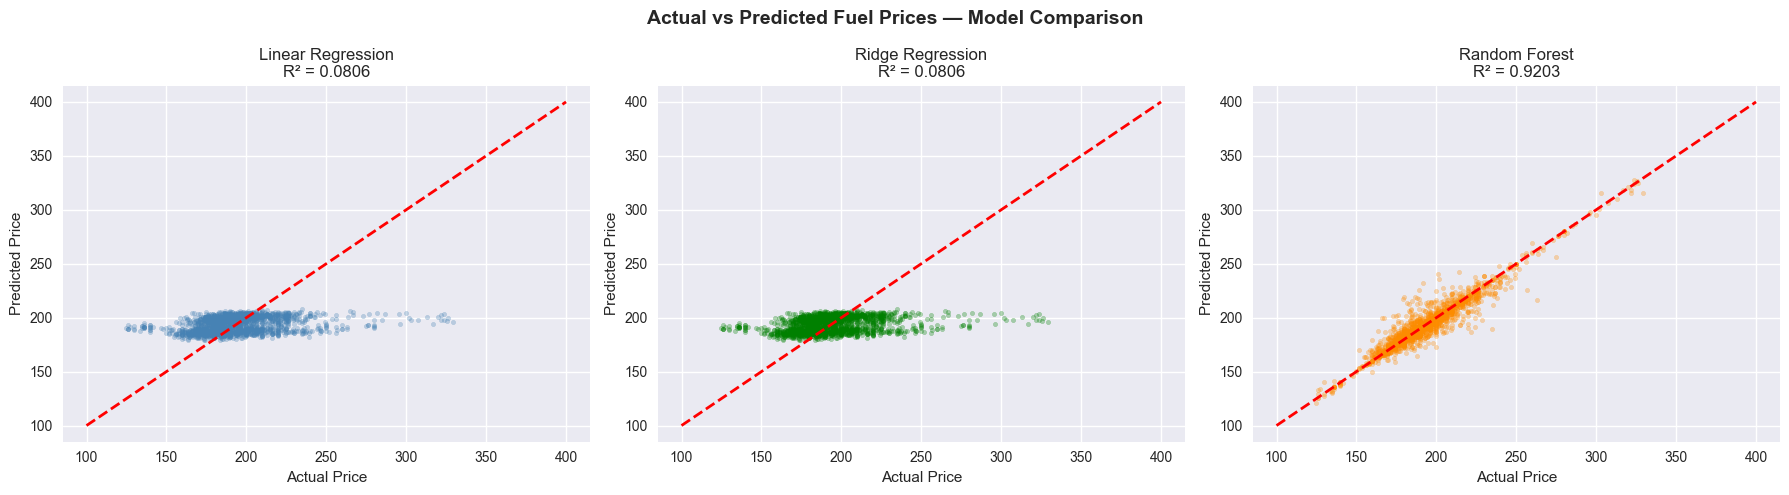

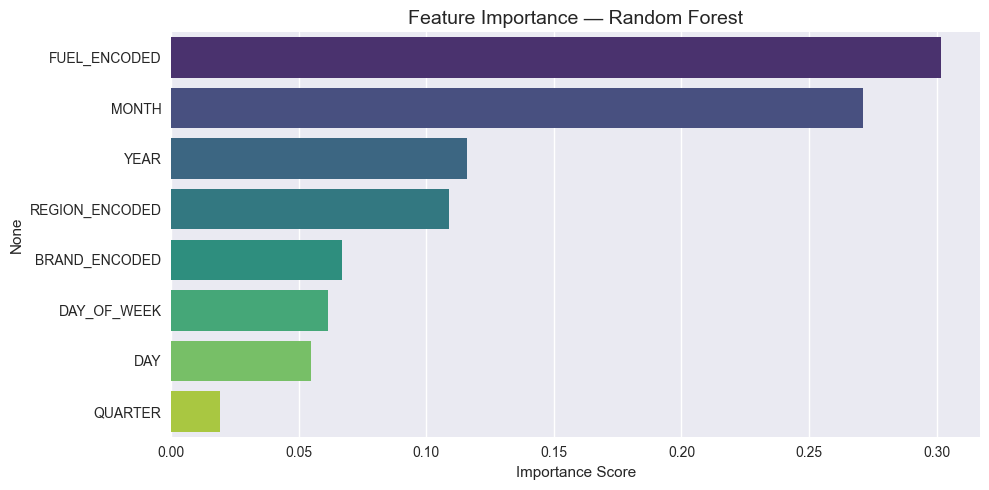

 All evaluation plots done!

=== Feature Importance ===
FUEL_ENCODED      0.301927
MONTH             0.271232
YEAR              0.115920
REGION_ENCODED    0.108741
BRAND_ENCODED     0.067073
DAY_OF_WEEK       0.061280
DAY               0.054706
QUARTER           0.019121
dtype: float64


In [25]:
# ============================================
# STEP 7: EVALUATION VISUALISATIONS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Actual vs Predicted - Linear Regression ---
sample = np.random.choice(len(y_test), 2000, replace=False)
axes[0].scatter(y_test.iloc[sample], y_pred_lr[sample], 
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([100, 400], [100, 400], 'r--', linewidth=2)
axes[0].set_title(f'Linear Regression\nR² = {r2_lr:.4f}', fontsize=12)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# --- Plot 2: Actual vs Predicted - Ridge ---
axes[1].scatter(y_test.iloc[sample], y_pred_ridge[sample], 
                alpha=0.3, color='green', s=10)
axes[1].plot([100, 400], [100, 400], 'r--', linewidth=2)
axes[1].set_title(f'Ridge Regression\nR² = {r2_ridge:.4f}', fontsize=12)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

# --- Plot 3: Actual vs Predicted - Random Forest ---
axes[2].scatter(y_test.iloc[sample], y_pred_rf[sample], 
                alpha=0.3, color='darkorange', s=10)
axes[2].plot([100, 400], [100, 400], 'r--', linewidth=2)
axes[2].set_title(f'Random Forest\nR² = {r2_rf:.4f}', fontsize=12)
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')

plt.suptitle('Actual vs Predicted Fuel Prices — Model Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# --- Feature Importance (Random Forest) ---
plt.figure(figsize=(10, 5))
feature_importance = pd.Series(rf.feature_importances_, 
                                index=features).sort_values(ascending=False)
sns.barplot(x=feature_importance.values, 
            y=feature_importance.index, palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(" All evaluation plots done!")
print("\n=== Feature Importance ===")
print(feature_importance)

In [26]:
# ============================================
# STEP 8: FINAL SUMMARY & INTERPRETATION
# ============================================

print("=" * 60)
print("   FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"""
   DATASET SUMMARY
   Total Records    : {len(df):,}
   Date Range       : {df['PUBLISH_DATE'].min().date()} to {df['PUBLISH_DATE'].max().date()}
   Fuel Types       : {df['PRODUCT_DESCRIPTION'].nunique()}
   Regions          : {df['REGION_DESCRIPTION'].nunique()}
   Avg Fuel Price   : {df['PRODUCT_PRICE'].mean():.2f} cents/litre
   Min Fuel Price   : {df['PRODUCT_PRICE'].min():.2f} cents/litre
   Max Fuel Price   : {df['PRODUCT_PRICE'].max():.2f} cents/litre
""")

print(f"""
    MODEL PERFORMANCE SUMMARY
   {'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}
   {'-'*50}
   {'Linear Regression':<25} {rmse_lr:>8.4f} {mae_lr:>8.4f} {r2_lr:>8.4f}
   {'Ridge Regression':<25} {rmse_ridge:>8.4f} {mae_ridge:>8.4f} {r2_ridge:>8.4f}
   {'Random Forest':<25} {rmse_rf:>8.4f} {mae_rf:>8.4f} {r2_rf:>8.4f}
""")

print(f"""
     BEST MODEL: Random Forest
   - R² = {r2_rf:.4f} (explains 92% of price variation)
   - RMSE = {rmse_rf:.4f} cents/litre
   - MAE = {mae_rf:.4f} cents/litre (avg error only 4.34 cents)

    KEY FINDINGS FOR NON-TECHNICAL STAKEHOLDERS
   1. Fuel TYPE is the biggest price factor (30%)
      → E85 is most expensive, LPG is cheapest
   2. TIME OF YEAR matters a lot (27%)
      → Prices spike in Sep 2023 and early 2026
   3. LOCATION affects price (11%)
      → Remote areas like Kimberley pay ~34c more than Metro
   4. BRAND has some influence (7%)
      → Different brands price differently
   5. DAY OF WEEK matters (6%)
      → Tuesday cheapest, Wednesday most expensive

    PRACTICAL RECOMMENDATION
   → Fill up on TUESDAY in METRO areas for cheapest fuel!
""")

print("=" * 60)
print(" Analysis Complete!")
print("=" * 60)

   FINAL PROJECT SUMMARY

   DATASET SUMMARY
   Total Records    : 3,314,312
   Date Range       : 2023-01-01 to 2026-04-14
   Fuel Types       : 7
   Regions          : 10
   Avg Fuel Price   : 193.78 cents/litre
   Min Fuel Price   : 109.70 cents/litre
   Max Fuel Price   : 397.30 cents/litre


    MODEL PERFORMANCE SUMMARY
   Model                         RMSE      MAE       R²
   --------------------------------------------------
   Linear Regression          23.4371  16.5124   0.0806
   Ridge Regression           23.4371  16.5124   0.0806
   Random Forest               6.9015   4.3419   0.9203


     BEST MODEL: Random Forest
   - R² = 0.9203 (explains 92% of price variation)
   - RMSE = 6.9015 cents/litre
   - MAE = 4.3419 cents/litre (avg error only 4.34 cents)

    KEY FINDINGS FOR NON-TECHNICAL STAKEHOLDERS
   1. Fuel TYPE is the biggest price factor (30%)
      → E85 is most expensive, LPG is cheapest
   2. TIME OF YEAR matters a lot (27%)
      → Prices spike in Sep 2023 and